# Gated Attention (Toy Study)

**Цель.** Показать идею gating: attention решает *куда смотреть*, а gate решает *сколько информации пропускать*.

В toy-режиме мы:
1) считаем обычный attention output,
2) вводим gate `g` (sigmoid),
3) сравниваем выходы и смотрим, как меняется "локальность"/амплитуда.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

## 1. Базовый attention

In [2]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)

def attention(Q, K, V):
    logits = Q @ K.T
    W = softmax(logits, axis=-1)
    out = W @ V
    return out, W

## 2. Gated attention (toy)

Мы добавим gate как функцию запроса `q_i`: 
$$g_i = \sigma(w^T q_i), \quad y_i = g_i \cdot (\text{Attn}(x))_i.$$

In [3]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def gated_attention(Q, K, V):
    out, W = attention(Q, K, V)
    w = np.random.randn(Q.shape[1])
    g = sigmoid(Q @ w)[:, None]   # (n,1)
    return g * out, W, g

## 3. Демонстрация на синтетике

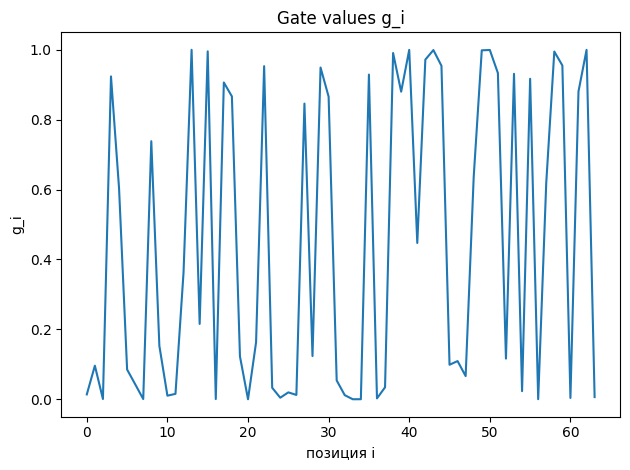

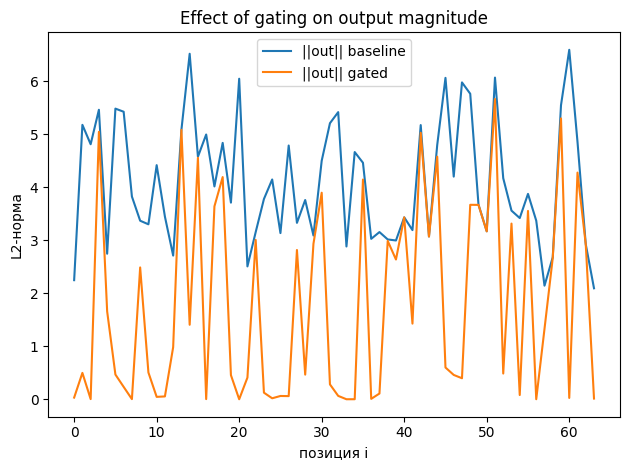

In [5]:
n, d = 64, 32
Q = np.random.randn(n, d)
K = np.random.randn(n, d)
V = np.random.randn(n, d)

out_base, W = attention(Q, K, V)
out_gate, W2, g = gated_attention(Q, K, V)

assert np.allclose(W, W2)

# --- График 1: значения gate ---
plt.figure()
plt.plot(g.squeeze())
plt.title("Gate values g_i")
plt.xlabel("позиция i")
plt.ylabel("g_i")
plt.tight_layout()
plt.savefig("../figures/gated_attention_gate_values.png", dpi=150, bbox_inches="tight")
plt.show()

# --- График 2: влияние gating на амплитуду ---
plt.figure()
plt.plot(np.linalg.norm(out_base, axis=1), label="||out|| baseline")
plt.plot(np.linalg.norm(out_gate, axis=1), label="||out|| gated")
plt.title("Effect of gating on output magnitude")
plt.xlabel("позиция i")
plt.ylabel("L2-норма")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/gated_attention_output_magnitude.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Вывод

Gating позволяет позиции *по-разному* пропускать информацию из attention-агрегации. В реальных архитектурах гейты обучаются и могут служить селективностью/стабилизацией.